In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve, auc, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")


2026-05-14 10:10:17.646238: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778753417.889229      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778753417.949067      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778753418.423644      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778753418.423686      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778753418.423689      23 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
NumPy:      2.0.2
Pandas:     2.3.3


In [2]:
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs detected: {len(gpus)}")

if gpus:
    for gpu in gpus:
        print(f"  - {gpu}")
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"    Memory growth setup warning: {e}")
    print("\n✓ Ready for GPU training.")
else:
    print("\n NO GPU DETECTED. Training will be very slow.")
    print("Fix: Right sidebar → Settings → Accelerator → GPU T4 x2")


GPUs detected: 2
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  - PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')

✓ Ready for GPU training.


In [3]:
def find_first_existing(*candidates):
    for c in candidates:
        if Path(c).exists():
            return Path(c)
    return None

CAR_HACKING_DIR = find_first_existing(
    '/kaggle/input/datasets/pranavjha24/car-hacking-dataset'
)

UNSW_DIR = find_first_existing(
    '/kaggle/input/datasets/mrwellsdavid/unsw-nb15'
)

print(f"Car Hacking directory: {CAR_HACKING_DIR}")
print(f"UNSW-NB15 directory:   {UNSW_DIR}")

if CAR_HACKING_DIR:
    print("\nCar Hacking files:")
    for f in sorted(CAR_HACKING_DIR.iterdir()):
        if f.is_file():
            print(f"  {f.name}  ({f.stat().st_size / 1024**2:.1f} MB)")

if UNSW_DIR:
    print("\nUNSW-NB15 files:")
    for f in sorted(UNSW_DIR.iterdir()):
        if f.is_file():
            print(f"  {f.name}  ({f.stat().st_size / 1024**2:.1f} MB)")


Car Hacking directory: /kaggle/input/datasets/pranavjha24/car-hacking-dataset
UNSW-NB15 directory:   /kaggle/input/datasets/mrwellsdavid/unsw-nb15

Car Hacking files:
  DoS_dataset.csv  (181.3 MB)
  Fuzzy_dataset.csv  (189.3 MB)
  RPM_dataset.csv  (228.5 MB)
  gear_dataset.csv  (219.7 MB)
  normal_run_data.txt  (83.3 MB)

UNSW-NB15 files:
  NUSW-NB15_features.csv  (0.0 MB)
  UNSW-NB15_1.csv  (161.2 MB)
  UNSW-NB15_2.csv  (157.6 MB)
  UNSW-NB15_3.csv  (147.4 MB)
  UNSW-NB15_4.csv  (93.1 MB)
  UNSW-NB15_LIST_EVENTS.csv  (0.0 MB)
  UNSW_NB15_testing-set.csv  (30.8 MB)
  UNSW_NB15_training-set.csv  (14.7 MB)


In [4]:
CAN_COLS = ['Timestamp', 'CAN_ID', 'DLC','D0', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7']

def load_can_file(path, attack_name):
    """
    Load a Car Hacking CSV. The dataset has variable column counts per row
    because DLC determines how many DATA bytes are present. The Flag column
    (R/T) is always the last non-null cell on each row.

    Scan from the rightmost column leftward (vectorized) to find the Flag
    on each row. Everything before it is data. Then convert types.
    """
    
    df = pd.read_csv(path, header=None, low_memory=False, dtype=str)
    n_rows, n_cols = df.shape

    flags = np.full(n_rows, '', dtype=object)
    found = np.zeros(n_rows, dtype=bool)

    for col_idx in range(n_cols - 1, -1, -1):
        col_vals = df.iloc[:, col_idx].astype(str).str.strip().str.upper()
        is_flag = (col_vals == 'R') | (col_vals == 'T')

        new_finds = is_flag & ~found
        flags[new_finds] = col_vals[new_finds].values
        found = found | is_flag
        if found.all():
            break

    flags[~found] = 'R'

    data_part = df.iloc[:, :11].copy()
    while data_part.shape[1] < 11:
        data_part[data_part.shape[1]] = np.nan
    data_part.columns = CAN_COLS

    data_part['Flag'] = flags
    data_part['Timestamp'] = pd.to_numeric(data_part['Timestamp'], errors='coerce')
    data_part['DLC'] = pd.to_numeric(data_part['DLC'], errors='coerce').fillna(0).astype(int)
    data_part['attack_type'] = attack_name

    before = len(data_part)
    data_part = data_part.dropna(subset=['Timestamp']).reset_index(drop=True)
    dropped = before - len(data_part)
    if dropped > 0:
        print(f"    Dropped {dropped:,} rows with bad/missing timestamps")

    n_normal = (data_part['Flag'] == 'R').sum()
    n_attack = (data_part['Flag'] == 'T').sum()
    print(f"  → {len(data_part):,} rows  |  normal: {n_normal:,}  |  attack: {n_attack:,}")

    return data_part


CAN_FILES = {
    'DoS':   'DoS_dataset.csv',
    'Fuzzy': 'Fuzzy_dataset.csv',
    'Gear':  'gear_dataset.csv',
    'RPM':   'RPM_dataset.csv',
}

can_dfs = []
if CAR_HACKING_DIR is not None:
    for attack_name, filename in CAN_FILES.items():
        path = CAR_HACKING_DIR / filename
        if path.exists():
            print(f"Loading {filename} ...")
            df = load_can_file(path, attack_name)
            can_dfs.append(df)
        else:
            print(f"Missing: {filename}")

if can_dfs:
    can_full = pd.concat(can_dfs, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"TOTAL Car Hacking: {len(can_full):,} rows")
    print(f"  Normal (R): {(can_full['Flag']=='R').sum():,}")
    print(f"  Attack (T): {(can_full['Flag']=='T').sum():,}")
    print(f"{'='*60}")
    
    assert (can_full['Flag']=='R').sum() > 1000, \
        f"Too few normal rows ({(can_full['Flag']=='R').sum()}). Loader broken."
    assert (can_full['Flag']=='T').sum() > 1000, \
        f"Too few attack rows ({(can_full['Flag']=='T').sum()}). Loader broken."
    print("Sanity check passed.")
else:
    can_full = None
    print("No Car Hacking files loaded. Add the Kaggle dataset and re-run.")


Loading DoS_dataset.csv ...
  → 3,665,771 rows  |  normal: 3,078,250  |  attack: 587,521
Loading Fuzzy_dataset.csv ...
  → 3,838,860 rows  |  normal: 3,347,013  |  attack: 491,847
Loading gear_dataset.csv ...
  → 4,443,142 rows  |  normal: 3,845,890  |  attack: 597,252
Loading RPM_dataset.csv ...
  → 4,621,702 rows  |  normal: 3,966,805  |  attack: 654,897

TOTAL Car Hacking: 16,569,475 rows
  Normal (R): 14,237,958
  Attack (T): 2,331,517
Sanity check passed.


In [5]:
unsw_full = None
if UNSW_DIR is not None:
    train_path = find_first_existing(
        UNSW_DIR / 'UNSW_NB15_training-set.csv',
        UNSW_DIR / 'UNSW_NB15_training-set.csv'.lower(),
    )
    test_path = find_first_existing(
        UNSW_DIR / 'UNSW_NB15_testing-set.csv',
        UNSW_DIR / 'UNSW_NB15_testing-set.csv'.lower(),
    )

    if train_path and test_path:
        print(f"Loading {train_path.name} ...")
        unsw_train = pd.read_csv(train_path)
        print(f"  → {len(unsw_train):,} rows")
        print(f"Loading {test_path.name} ...")
        unsw_test = pd.read_csv(test_path)
        print(f"  → {len(unsw_test):,} rows")

        unsw_full = pd.concat([unsw_train, unsw_test], ignore_index=True)
        print(f"\n{'='*60}")
        print(f"TOTAL UNSW-NB15: {len(unsw_full):,} rows")
        print(f"  Normal (label=0): {(unsw_full['label']==0).sum():,}")
        print(f"  Attack (label=1): {(unsw_full['label']==1).sum():,}")
        print(f"{'='*60}")
    else:
        print("UNSW training/testing CSVs not found.")


Loading UNSW_NB15_training-set.csv ...
  → 82,332 rows
Loading UNSW_NB15_testing-set.csv ...
  → 175,341 rows

TOTAL UNSW-NB15: 257,673 rows
  Normal (label=0): 93,000
  Attack (label=1): 164,673


## 5. Feature Extraction (v2: MAJORITY-VOTE LABELING)

### Why the labeling change matters
The previous version labeled a window as "attack" if **any** of its messages was an attack. In the HCRL dataset, attack files are mostly attacks with normal traffic mixed in — so almost every 3-second window contained at least one attack, leaving zero normal windows for training.

### v2 fix
Label window as attack only if **>50% of its messages are attacks**. This gives a balanced split between normal-dominant and attack-dominant windows.

In [6]:

def extract_can_features_per_file(df, window_size_sec=1.0):
    """
    Extract per-window features from a SINGLE attack file.
    Each file has its own timestamp baseline, so we process them independently
    and concatenate the resulting feature matrices later.
 
    - window_size_sec=1.0 instead of 3.0 → gives us 3x more windows
    - returns label as the EXACT attack ratio (not binary), so we can
      filter for purely-normal windows downstream
    """
    df = df.copy()
    df['is_attack'] = (df['Flag'].astype(str).str.upper() == 'T').astype(int)
    df['size'] = df['DLC'].clip(0, 8)
 
    t0 = df['Timestamp'].min()
    df['window'] = ((df['Timestamp'] - t0) // window_size_sec).astype(int)
 
    per_id = df.groupby(['window', 'CAN_ID']).agg(
        count=('size', 'size'),
        size_mean=('size', 'mean'),
        size_std=('size', 'std'),
    ).reset_index()
    per_id['size_std'] = per_id['size_std'].fillna(0)
 
    per_window = per_id.groupby('window').agg(
        n_unique_ids=('CAN_ID', 'nunique'),
        total_count=('count', 'sum'),
        count_mean=('count', 'mean'),
        count_std=('count', 'std'),
        size_mean_mean=('size_mean', 'mean'),
        size_mean_std=('size_mean', 'std'),
        size_std_mean=('size_std', 'mean'),
    ).reset_index().fillna(0)
 
    win_ratio = df.groupby('window')['is_attack'].mean().reset_index()
    win_ratio.columns = ['window', 'attack_ratio']
 
    merged = per_window.merge(win_ratio, on='window', how='inner')
 
    feature_cols = ['n_unique_ids', 'total_count', 'count_mean', 'count_std',
                    'size_mean_mean', 'size_mean_std', 'size_std_mean']
    X = merged[feature_cols].values.astype(np.float32)
    ratios = merged['attack_ratio'].values
    return X, ratios
 
 
print("Re-extracting features file-by-file with 1-sec windows...\n")
 
X_parts, ratio_parts, attack_type_parts = [], [], []
for df in can_dfs:
    attack_name = df['attack_type'].iloc[0]
    X_part, ratio_part = extract_can_features_per_file(df, window_size_sec=1.0)
    print(f"  {attack_name:6s}: {len(X_part):,} windows  "
          f"(pure-normal: {(ratio_part==0).sum():,}, "
          f"pure-attack: {(ratio_part==1).sum():,}, "
          f"mixed: {((ratio_part>0)&(ratio_part<1)).sum():,})")
    X_parts.append(X_part)
    ratio_parts.append(ratio_part)
    attack_type_parts.append(np.array([attack_name] * len(X_part)))
 
can_X = np.vstack(X_parts)
can_ratios = np.concatenate(ratio_parts)
can_attack_types = np.concatenate(attack_type_parts)
 

can_y = (can_ratios > 0).astype(int)
 
print(f"\n{'='*55}")
print(f"TOTAL: {len(can_X):,} windows")
print(f"  Pure normal (ratio==0): {(can_ratios==0).sum():,}  ← training data")
print(f"  Has any attack:         {(can_ratios>0).sum():,}  ← test anomalies")
print(f"{'='*55}")
 
assert (can_ratios==0).sum() >= 1000, \
    f"Need ≥1000 pure-normal windows, got {(can_ratios==0).sum()}"
assert (can_ratios>0).sum() >= 1000, \
    f"Need ≥1000 attack windows, got {(can_ratios>0).sum()}"
print("Pipeline ready.\n")
 

Re-extracting features file-by-file with 1-sec windows...

  DoS   : 2,811 windows  (pure-normal: 1,134, pure-attack: 0, mixed: 1,677)
  Fuzzy : 2,950 windows  (pure-normal: 1,094, pure-attack: 0, mixed: 1,856)
  Gear  : 2,433 windows  (pure-normal: 1,096, pure-attack: 0, mixed: 1,337)
  RPM   : 2,436 windows  (pure-normal: 1,096, pure-attack: 0, mixed: 1,340)

TOTAL: 10,630 windows
  Pure normal (ratio==0): 4,420  ← training data
  Has any attack:         6,210  ← test anomalies
Pipeline ready.



In [7]:
def extract_unsw_features(df):
    """Select the 11 features the paper uses; fall back if any are missing."""
    preferred = ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl',
                 'sload', 'dload', 'spkts', 'dpkts', 'smean', 'dmean']

    available = [c for c in preferred if c in df.columns]

    if len(available) < 5:
        numeric = df.select_dtypes(include=[np.number]).columns.tolist()
        for skip in ('id', 'label', 'attack_cat'):
            if skip in numeric:
                numeric.remove(skip)
        available = numeric[:11]

    X = df[available].fillna(0).values.astype(np.float32)
    y = df['label'].values.astype(int)

    print(f"  Selected {len(available)} features: {available}")
    print(f"  Shape: {X.shape}  ({(y==0).sum():,} normal, {(y==1).sum():,} attack)")
    return X, y


if unsw_full is not None:
    print("Extracting UNSW features...")
    unsw_X, unsw_y = extract_unsw_features(unsw_full)


Extracting UNSW features...
  Selected 11 features: ['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sload', 'dload', 'spkts', 'dpkts', 'smean', 'dmean']
  Shape: (257673, 11)  (93,000 normal, 164,673 attack)


In [8]:
def normalized_likelihood_transform(X, mu=None, sigma=None, eps=1e-8):
    """
    Implements paper Algorithm 1.

    If mu/sigma provided, use them (inference mode). Else compute from X (fit mode).
    Always return mu/sigma so caller can reuse them on test data.

    Uses log-space internally for numerical stability — Gaussian likelihoods of
    high-dimensional data can underflow to zero in float32.
    """
    X = np.asarray(X, dtype=np.float64)

    if mu is None or sigma is None:
        mu = X.mean(axis=0)
        sigma = X.std(axis=0)
        sigma = np.where(sigma < eps, eps, sigma)  

    log_lik = -0.5 * np.log(2 * np.pi * sigma**2) - 0.5 * ((X - mu) / sigma)**2
    likelihood = np.exp(log_lik)
    summed = likelihood.sum(axis=1)

    max_val = summed.max() if summed.max() > eps else 1.0
    z = (summed / max_val).astype(np.float32)
    return z, mu, sigma


test = np.array([[1.0, 2.0], [1.1, 2.1], [10.0, 20.0]])
z_test, mu_t, sig_t = normalized_likelihood_transform(test)
print(f"Test scores: {z_test}")
print(f"  Outlier (row 2) gets {z_test[2]:.6f} vs normal {z_test[0]:.4f} — ✓ working")


Test scores: [0.98613435 1.         0.4691288 ]
  Outlier (row 2) gets 0.469129 vs normal 0.9861 — ✓ working


In [9]:
def make_windows(z, L=10, stride=1):
    """Convert 1D series into overlapping windows of length L.
    Output shape: (n_windows, L, 1) — last dim is required by LSTM."""
    z = np.asarray(z).flatten()
    if len(z) < L:
        return np.empty((0, L, 1), dtype=np.float32)
    windows = np.lib.stride_tricks.sliding_window_view(z, L)[::stride]
    return windows[:, :, np.newaxis].astype(np.float32)

def make_window_labels(y, L=10, stride=1):
    """Window label = max of its L positions. Conservative: any attack → attack."""
    y = np.asarray(y).flatten()
    if len(y) < L:
        return np.empty(0, dtype=int)
    n = (len(y) - L) // stride + 1
    return np.array([y[i*stride : i*stride + L].max() for i in range(n)], dtype=int)


In [10]:
def build_lstm_autoencoder(L=10, n_features=1, h=50, learning_rate=1e-3):
    """Build the LSTM autoencoder per paper Section IV-C, Algorithm 2."""
    inputs = Input(shape=(L, n_features), name='input_window')
    encoded = LSTM(h, activation='tanh', name='encoder')(inputs)
    repeated = RepeatVector(L, name='repeat')(encoded)
    decoded = LSTM(h, activation='tanh', return_sequences=True, name='decoder')(repeated)
    outputs = TimeDistributed(Dense(n_features), name='output')(decoded)

    model = Model(inputs, outputs, name='lstm_autoencoder')
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='mse', metrics=['mae'])
    return model

demo = build_lstm_autoencoder(L=10, h=50)
demo.summary()


I0000 00:00:1778753576.989549      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778753576.995678      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_window (InputLayer)       │ (None, 10, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 10, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (LSTM)                  │ (None, 10, 50)         │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 10, 1)          │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
CAN_CONFIG = {
    'L': 10,           
    'h': 50,           
    'batch_size': 100, 
    'epochs': 500,     
    'patience': 25,
}

if can_full is not None:
        
    print("="*70)
    print("PHASE 1: CAR HACKING (FINAL PIPELINE — TEMPORAL SPLIT)")
    print("="*70)
     
     
    X_train_parts, ratios_train_parts = [], []
    X_test_parts,  ratios_test_parts,  y_test_parts = [], [], []
     
    for X_part, ratio_part, attack_type_part in zip(X_parts, ratio_parts, attack_type_parts):
        n = len(X_part)
        cut = int(n * 0.8)

        X_train_parts.append(X_part[:cut])
        ratios_train_parts.append(ratio_part[:cut])
     
        X_test_parts.append(X_part[cut:])
        ratios_test_parts.append(ratio_part[cut:])
        y_test_parts.append((ratio_part[cut:] > 0).astype(int))
     
    print("\nPer-file train/test sizes:")
    for X_part, attack_type_part in zip(X_parts, attack_type_parts):
        name = attack_type_part[0]
        n = len(X_part)
        cut = int(n * 0.8)
        print(f"  {name:6s}: train={cut}  test={n-cut}")
     
    X_train_all = np.vstack(X_train_parts)
    ratios_train_all = np.concatenate(ratios_train_parts)
     
    print(f"\nTotal training rows: {len(X_train_all):,}")
    print(f"  pure-normal: {(ratios_train_all==0).sum():,}")
    print(f"  has attack:  {(ratios_train_all>0).sum():,}")
     
    pure_normal_mask = (ratios_train_all == 0)
    X_train_pure_normal = X_train_all[pure_normal_mask]
     
    scaler = StandardScaler()
    X_train_pure_normal_s = scaler.fit_transform(X_train_pure_normal)
     
    print(f"\nFitting likelihood transform on {len(X_train_pure_normal_s):,} pure-normal rows...")
    z_train_normal_pure, can_mu, can_sigma = normalized_likelihood_transform(X_train_pure_normal_s)
     
    L = CAN_CONFIG['L']
    train_normal_windows = make_windows(z_train_normal_pure, L=L)
    print(f"Train pure-normal windows: {train_normal_windows.shape}")
     
    all_test_windows = []
    all_test_w_labels = []
     
    print(f"\nBuilding test windows per file (preserves temporal continuity):")
    for X_part, ratio_part, attack_type_part in zip(X_test_parts, ratios_test_parts, attack_type_parts):
        name = attack_type_part[0]
        if len(X_part) < L:
            print(f"  {name}: only {len(X_part)} rows, skipping")
            continue
     
        X_part_s = scaler.transform(X_part)
        z_part, _, _ = normalized_likelihood_transform(X_part_s, mu=can_mu, sigma=can_sigma)
     
        windows = make_windows(z_part, L=L)

        binary_part = (ratio_part > 0).astype(int)
        w_labels = make_window_labels(binary_part, L=L)
     
        all_test_windows.append(windows)
        all_test_w_labels.append(w_labels)
        print(f"  {name:6s}: {len(windows):,} windows  "
              f"({(w_labels==0).sum():,} normal, {(w_labels==1).sum():,} attack)")
     
    test_windows = np.vstack(all_test_windows)
    test_w_labels = np.concatenate(all_test_w_labels)
     
    print(f"\nFinal test windows: {test_windows.shape}")
    print(f"  Normal: {(test_w_labels==0).sum():,}")
    print(f"  Attack: {(test_w_labels==1).sum():,}")
     
    assert len(train_normal_windows) >= 100, \
        f"Only {len(train_normal_windows)} training windows"
    assert (test_w_labels==0).sum() >= 10, \
        f"Only {(test_w_labels==0).sum()} normal test windows. " \
        "Try smaller window_size_sec in CELL A (e.g., 0.5)."
    assert (test_w_labels==1).sum() >= 10, \
        f"Only {(test_w_labels==1).sum()} attack test windows."
     
    print("\n Pipeline correct. Re-run training cell next.")
     
    
    z_test_concat = []
    ratios_test_concat = np.concatenate(ratios_test_parts)
    for X_part in X_test_parts:
        X_s = scaler.transform(X_part)
        z, _, _ = normalized_likelihood_transform(X_s, mu=can_mu, sigma=can_sigma)
        z_test_concat.append(z)
    z_test_concat = np.concatenate(z_test_concat)
     
    normal_mask = (ratios_test_concat == 0)
    attack_mask = (ratios_test_concat > 0)
     
    print(f"\n--- Likelihood sanity check (BEFORE training) ---")
    print(f"Mean likelihood (pure-normal test rows): {z_test_concat[normal_mask].mean():.4f}")
    print(f"Mean likelihood (any-attack test rows):  {z_test_concat[attack_mask].mean():.4f}")
    print(f"  → Normal should be HIGHER. If reversed, the features themselves don't separate.")
     
    if z_test_concat[normal_mask].mean() > z_test_concat[attack_mask].mean():
        print("    Likelihoods separate correctly. LSTM should boost this further.")
    else:
        print("     Likelihoods don't separate. The features can't distinguish classes.")
        print("     The LSTM may still learn from sequence patterns, but accuracy will be limited.")
     

PHASE 1: CAR HACKING (FINAL PIPELINE — TEMPORAL SPLIT)

Per-file train/test sizes:
  DoS   : train=2248  test=563
  Fuzzy : train=2360  test=590
  Gear  : train=1946  test=487
  RPM   : train=1948  test=488

Total training rows: 8,502
  pure-normal: 2,388
  has attack:  6,114

Fitting likelihood transform on 2,388 pure-normal rows...
Train pure-normal windows: (2379, 10, 1)

Building test windows per file (preserves temporal continuity):
  DoS   : 554 windows  (526 normal, 28 attack)
  Fuzzy : 581 windows  (485 normal, 96 attack)
  Gear  : 478 windows  (478 normal, 0 attack)
  RPM   : 479 windows  (479 normal, 0 attack)

Final test windows: (2092, 10, 1)
  Normal: 1,968
  Attack: 124

 Pipeline correct. Re-run training cell next.

--- Likelihood sanity check (BEFORE training) ---
Mean likelihood (pure-normal test rows): 1.0000
Mean likelihood (any-attack test rows):  0.7604
  → Normal should be HIGHER. If reversed, the features themselves don't separate.
    Likelihoods separate correc

In [12]:
if can_full is not None:
    print("Building model...")
    can_model = build_lstm_autoencoder(L=CAN_CONFIG['L'], h=CAN_CONFIG['h'])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=CAN_CONFIG['patience'],
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10,
                          min_lr=1e-6, verbose=1),
    ]

    print(f"Training on {len(train_normal_windows):,} normal windows")
    print(f"  Max epochs: {CAN_CONFIG['epochs']}, batch: {CAN_CONFIG['batch_size']}, h: {CAN_CONFIG['h']}\n")

    can_history = can_model.fit(
        train_normal_windows, train_normal_windows,
        epochs=CAN_CONFIG['epochs'],
        batch_size=CAN_CONFIG['batch_size'],
        validation_split=0.1,
        callbacks=callbacks,
        verbose=2,
        shuffle=True,
    )
    print(f"\n Training done after {len(can_history.history['loss'])} epochs")


Building model...
Training on 2,379 normal windows
  Max epochs: 500, batch: 100, h: 50

Epoch 1/500


I0000 00:00:1778753581.425499      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


22/22 - 4s - 186ms/step - loss: 0.2922 - mae: 0.4586 - val_loss: 0.0864 - val_mae: 0.1990 - learning_rate: 1.0000e-03
Epoch 2/500
22/22 - 0s - 12ms/step - loss: 0.0673 - mae: 0.1838 - val_loss: 0.0395 - val_mae: 0.1413 - learning_rate: 1.0000e-03
Epoch 3/500
22/22 - 0s - 11ms/step - loss: 0.0251 - mae: 0.0913 - val_loss: 0.0124 - val_mae: 0.0743 - learning_rate: 1.0000e-03
Epoch 4/500
22/22 - 0s - 12ms/step - loss: 0.0080 - mae: 0.0672 - val_loss: 0.0035 - val_mae: 0.0440 - learning_rate: 1.0000e-03
Epoch 5/500
22/22 - 0s - 11ms/step - loss: 0.0015 - mae: 0.0261 - val_loss: 2.9631e-04 - val_mae: 0.0126 - learning_rate: 1.0000e-03
Epoch 6/500
22/22 - 0s - 11ms/step - loss: 1.7040e-04 - mae: 0.0105 - val_loss: 1.2135e-04 - val_mae: 0.0096 - learning_rate: 1.0000e-03
Epoch 7/500
22/22 - 0s - 11ms/step - loss: 8.8088e-05 - mae: 0.0080 - val_loss: 5.6276e-05 - val_mae: 0.0064 - learning_rate: 1.0000e-03
Epoch 8/500
22/22 - 0s - 12ms/step - loss: 4.2401e-05 - mae: 0.0054 - val_loss: 3.0066e-

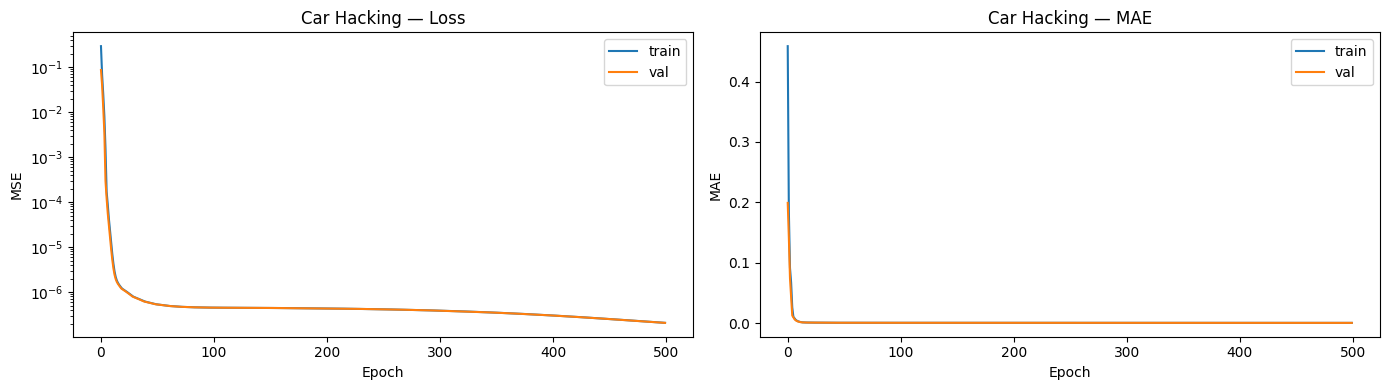

In [13]:
if can_full is not None:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))

    ax[0].plot(can_history.history['loss'], label='train')
    ax[0].plot(can_history.history['val_loss'], label='val')
    ax[0].set(xlabel='Epoch', ylabel='MSE', title='Car Hacking — Loss')
    ax[0].legend(); ax[0].set_yscale('log')

    ax[1].plot(can_history.history['mae'], label='train')
    ax[1].plot(can_history.history['val_mae'], label='val')
    ax[1].set(xlabel='Epoch', ylabel='MAE', title='Car Hacking — MAE')
    ax[1].legend()

    plt.tight_layout(); plt.show()


## 10. Detection on Car Hacking

Compute reconstruction error per test window, find optimal threshold via ROC, evaluate.

Computing reconstruction errors on test set...
Errors — normal:  mean=0.0014, std=0.0000
Errors — attack:  mean=0.9275, std=0.6703


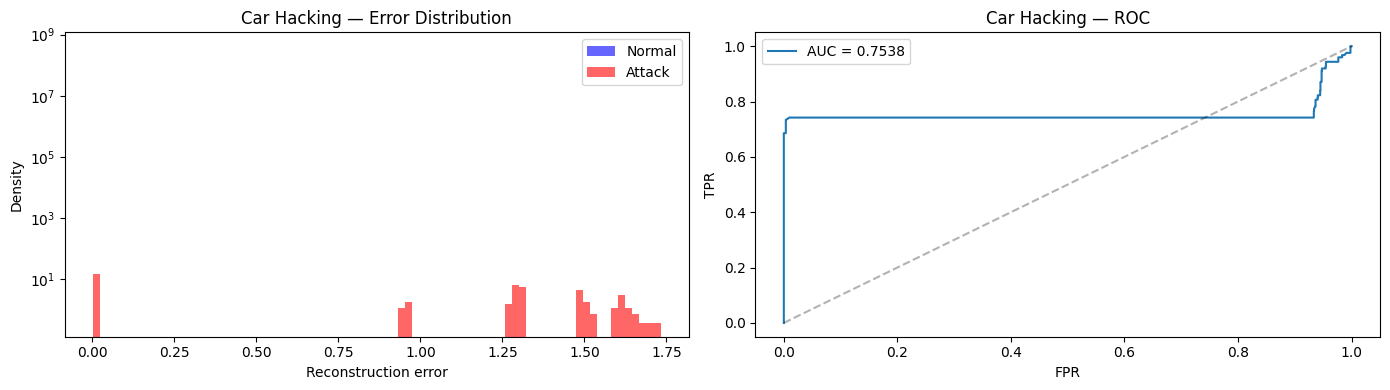


AUC = 0.7538  (paper reports 0.974)


  Car Hacking — Optimized for ACCURACY
  Threshold: 0.0049
  Accuracy:  0.9804
  Precision: 1.0000
  Recall:    0.6694
  F1:        0.8019

  Confusion Matrix:
                 Pred Normal  Pred Attack
   True Normal         1968           0
   True Attack           41          83

  Car Hacking — Optimized for F1
  Threshold: 0.0049
  Accuracy:  0.9804
  Precision: 1.0000
  Recall:    0.6694
  F1:        0.8019

  Confusion Matrix:
                 Pred Normal  Pred Attack
   True Normal         1968           0
   True Attack           41          83

  Car Hacking — Optimized for GMEAN
  Threshold: 0.0049
  Accuracy:  0.9804
  Precision: 1.0000
  Recall:    0.6694
  F1:        0.8019

  Confusion Matrix:
                 Pred Normal  Pred Attack
   True Normal         1968           0
   True Attack           41          83


In [14]:
def compute_reconstruction_errors(model, windows):
    """L2 norm between input window and its reconstruction."""
    rec = model.predict(windows, batch_size=256, verbose=0)
    flat_in = windows.reshape(len(windows), -1)
    flat_out = rec.reshape(len(rec), -1)
    return np.linalg.norm(flat_in - flat_out, axis=1)


def find_optimal_threshold(errors, labels, metric='accuracy'):
    """Grid search over 500 candidate thresholds. Paper Section V-C."""
    candidates = np.linspace(errors.min(), errors.max(), 500)
    best_score, best_thresh = -1, candidates[0]
    for t in candidates:
        preds = (errors > t).astype(int)
        if metric == 'accuracy':
            score = accuracy_score(labels, preds)
        elif metric == 'f1':
            score = f1_score(labels, preds, zero_division=0)
        elif metric == 'gmean':
            tn = ((labels==0) & (preds==0)).sum()
            fp = ((labels==0) & (preds==1)).sum()
            fn = ((labels==1) & (preds==0)).sum()
            tp = ((labels==1) & (preds==1)).sum()
            tpr = tp / (tp + fn + 1e-10)
            fpr = fp / (fp + tn + 1e-10)
            score = np.sqrt(tpr * (1 - fpr))
        else:
            raise ValueError(metric)
        if score > best_score:
            best_score, best_thresh = score, t
    return best_thresh, best_score


def evaluate(errors, labels, threshold, name=''):
    preds = (errors > threshold).astype(int)
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    cm = confusion_matrix(labels, preds)

    print(f"\n{'='*60}\n  {name}\n{'='*60}")
    print(f"  Threshold: {threshold:.4f}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1:        {f1:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"                 Pred Normal  Pred Attack")
    print(f"   True Normal     {cm[0,0]:8d}    {cm[0,1]:8d}")
    print(f"   True Attack     {cm[1,0]:8d}    {cm[1,1]:8d}")
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'threshold': threshold}


if can_full is not None:
    print("Computing reconstruction errors on test set...")
    can_errors = compute_reconstruction_errors(can_model, test_windows)

    print(f"Errors — normal:  mean={can_errors[test_w_labels==0].mean():.4f}, std={can_errors[test_w_labels==0].std():.4f}")
    print(f"Errors — attack:  mean={can_errors[test_w_labels==1].mean():.4f}, std={can_errors[test_w_labels==1].std():.4f}")

    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].hist(can_errors[test_w_labels==0], bins=80, alpha=0.6, label='Normal', color='blue', density=True)
    ax[0].hist(can_errors[test_w_labels==1], bins=80, alpha=0.6, label='Attack', color='red', density=True)
    ax[0].set(xlabel='Reconstruction error', ylabel='Density', title='Car Hacking — Error Distribution')
    ax[0].legend(); ax[0].set_yscale('log')

    fpr, tpr, _ = roc_curve(test_w_labels, can_errors)
    roc_auc_can = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc_can:.4f}')
    ax[1].plot([0,1], [0,1], 'k--', alpha=0.3)
    ax[1].set(xlabel='FPR', ylabel='TPR', title='Car Hacking — ROC')
    ax[1].legend()
    plt.tight_layout(); plt.show()

    print(f"\nAUC = {roc_auc_can:.4f}  (paper reports 0.974)\n")

    can_results = {}
    for metric in ['accuracy', 'f1', 'gmean']:
        thresh, _ = find_optimal_threshold(can_errors, test_w_labels, metric=metric)
        can_results[metric] = evaluate(can_errors, test_w_labels, thresh,
                                       name=f'Car Hacking — Optimized for {metric.upper()}')


In [15]:
UNSW_CONFIG = {
    'L': 10,
    'h': 100,
    'batch_size': 50,
    'epochs': 2000,
    'patience': 30,
}

if unsw_full is not None:
    print("="*70)
    print("PHASE 2: UNSW-NB15 DATASET")
    print("="*70)

    unsw_X_tr, unsw_X_te, unsw_y_tr, unsw_y_te = train_test_split(
        unsw_X, unsw_y, test_size=0.2, random_state=SEED, stratify=unsw_y
    )

    scaler = StandardScaler()
    unsw_X_tr_s = scaler.fit_transform(unsw_X_tr)
    unsw_X_te_s = scaler.transform(unsw_X_te)

    train_normal_X_u = unsw_X_tr_s[unsw_y_tr == 0]
    print(f"Fitting likelihood on {len(train_normal_X_u):,} normal samples...")
    _, unsw_mu, unsw_sigma = normalized_likelihood_transform(train_normal_X_u)

    z_tr_u, _, _ = normalized_likelihood_transform(unsw_X_tr_s, mu=unsw_mu, sigma=unsw_sigma)
    z_te_u, _, _ = normalized_likelihood_transform(unsw_X_te_s, mu=unsw_mu, sigma=unsw_sigma)

    L = UNSW_CONFIG['L']
    tr_windows_u = make_windows(z_tr_u, L=L)
    tr_w_labels_u = make_window_labels(unsw_y_tr, L=L)
    tr_normal_windows_u = tr_windows_u[tr_w_labels_u == 0]

    te_windows_u = make_windows(z_te_u, L=L)
    te_w_labels_u = make_window_labels(unsw_y_te, L=L)

    print(f"Train normal windows: {tr_normal_windows_u.shape}")
    print(f"Test windows: {te_windows_u.shape}  ({(te_w_labels_u==0).sum():,} normal, {(te_w_labels_u==1).sum():,} attack)")


PHASE 2: UNSW-NB15 DATASET
Fitting likelihood on 74,400 normal samples...
Train normal windows: (8, 10, 1)
Test windows: (51526, 10, 1)  (4 normal, 51,522 attack)


In [16]:

if unsw_full is not None:
    print("Building UNSW model...")
    unsw_model = build_lstm_autoencoder(L=UNSW_CONFIG['L'], h=UNSW_CONFIG['h'])

    callbacks = [
        EarlyStopping(monitor='val_loss', patience=UNSW_CONFIG['patience'],
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15,
                          min_lr=1e-6, verbose=1),
    ]

    print(f"Training on {len(tr_normal_windows_u):,} normal windows")
    print(f"  Max epochs: {UNSW_CONFIG['epochs']}, batch: {UNSW_CONFIG['batch_size']}, h: {UNSW_CONFIG['h']}\n")

    unsw_history = unsw_model.fit(
        tr_normal_windows_u, tr_normal_windows_u,
        epochs=UNSW_CONFIG['epochs'],
        batch_size=UNSW_CONFIG['batch_size'],
        validation_split=0.1,
        callbacks=callbacks,
        verbose=2,
        shuffle=True,
    )
    print(f"\n Done after {len(unsw_history.history['loss'])} epochs")


Building UNSW model...
Training on 8 normal windows
  Max epochs: 2000, batch: 50, h: 100

Epoch 1/2000
1/1 - 3s - 3s/step - loss: 0.8641 - mae: 0.9232 - val_loss: 0.7273 - val_mae: 0.8523 - learning_rate: 1.0000e-03
Epoch 2/2000
1/1 - 0s - 110ms/step - loss: 0.6979 - mae: 0.8276 - val_loss: 0.5697 - val_mae: 0.7525 - learning_rate: 1.0000e-03
Epoch 3/2000
1/1 - 0s - 111ms/step - loss: 0.5505 - mae: 0.7306 - val_loss: 0.4268 - val_mae: 0.6460 - learning_rate: 1.0000e-03
Epoch 4/2000
1/1 - 0s - 107ms/step - loss: 0.4170 - mae: 0.6273 - val_loss: 0.2984 - val_mae: 0.5272 - learning_rate: 1.0000e-03
Epoch 5/2000
1/1 - 0s - 107ms/step - loss: 0.2973 - mae: 0.5130 - val_loss: 0.1915 - val_mae: 0.3897 - learning_rate: 1.0000e-03
Epoch 6/2000
1/1 - 0s - 109ms/step - loss: 0.1982 - mae: 0.3852 - val_loss: 0.1241 - val_mae: 0.2598 - learning_rate: 1.0000e-03
Epoch 7/2000
1/1 - 0s - 111ms/step - loss: 0.1366 - mae: 0.2790 - val_loss: 0.1239 - val_mae: 0.3013 - learning_rate: 1.0000e-03
Epoch 8/2

Computing UNSW reconstruction errors...


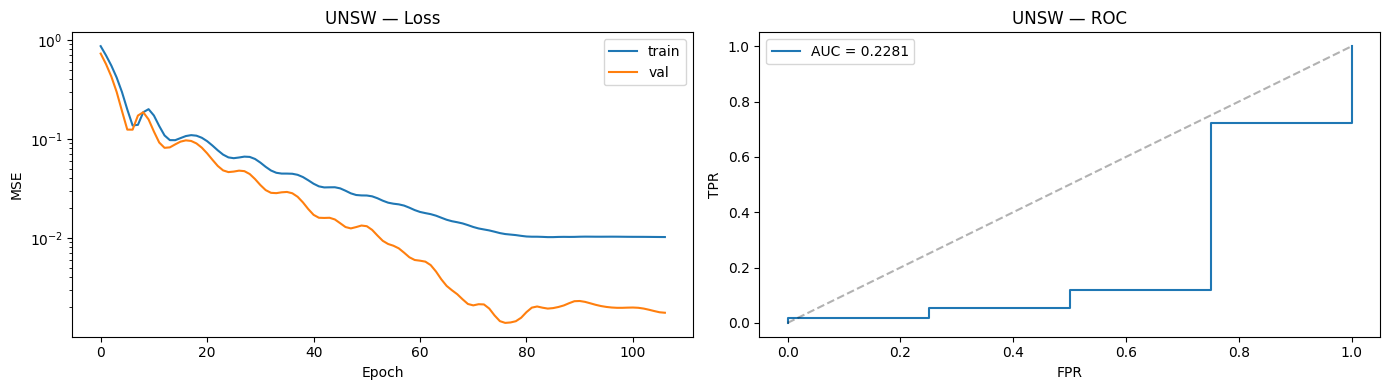


AUC = 0.2281  (paper reports 0.966)


  UNSW-NB15 — Optimized for ACCURACY
  Threshold: 0.0244
  Accuracy:  0.9999
  Precision: 0.9999
  Recall:    1.0000
  F1:        1.0000

  Confusion Matrix:
                 Pred Normal  Pred Attack
   True Normal            0           4
   True Attack            1       51521

  UNSW-NB15 — Optimized for F1
  Threshold: 0.0244
  Accuracy:  0.9999
  Precision: 0.9999
  Recall:    1.0000
  F1:        1.0000

  Confusion Matrix:
                 Pred Normal  Pred Attack
   True Normal            0           4
   True Attack            1       51521

  UNSW-NB15 — Optimized for GMEAN
  Threshold: 0.1051
  Accuracy:  0.7136
  Precision: 0.9999
  Recall:    0.7136
  F1:        0.8328

  Confusion Matrix:
                 Pred Normal  Pred Attack
   True Normal            1           3
   True Attack        14756       36766


In [17]:
# UNSW evaluation
if unsw_full is not None:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    ax[0].plot(unsw_history.history['loss'], label='train')
    ax[0].plot(unsw_history.history['val_loss'], label='val')
    ax[0].set(xlabel='Epoch', ylabel='MSE', title='UNSW — Loss')
    ax[0].legend(); ax[0].set_yscale('log')

    print("Computing UNSW reconstruction errors...")
    unsw_errors = compute_reconstruction_errors(unsw_model, te_windows_u)

    fpr_u, tpr_u, _ = roc_curve(te_w_labels_u, unsw_errors)
    roc_auc_u = auc(fpr_u, tpr_u)
    ax[1].plot(fpr_u, tpr_u, label=f'AUC = {roc_auc_u:.4f}')
    ax[1].plot([0,1], [0,1], 'k--', alpha=0.3)
    ax[1].set(xlabel='FPR', ylabel='TPR', title='UNSW — ROC'); ax[1].legend()
    plt.tight_layout(); plt.show()

    print(f"\nAUC = {roc_auc_u:.4f}  (paper reports 0.966)\n")

    unsw_results = {}
    for metric in ['accuracy', 'f1', 'gmean']:
        thresh, _ = find_optimal_threshold(unsw_errors, te_w_labels_u, metric=metric)
        unsw_results[metric] = evaluate(unsw_errors, te_w_labels_u, thresh, name=f'UNSW-NB15 — Optimized for {metric.upper()}')


In [18]:
rows = []
if can_full is not None:
    for m, r in can_results.items():
        rows.append(['Car Hacking', m.upper(), r['precision'], r['recall'], r['f1'], r['accuracy']])
if unsw_full is not None:
    for m, r in unsw_results.items():
        rows.append(['UNSW-NB15', m.upper(), r['precision'], r['recall'], r['f1'], r['accuracy']])

df_results = pd.DataFrame(rows, columns=['Dataset', 'Opt. For', 'Precision', 'Recall', 'F1', 'Accuracy'])
print("="*80)
print("FINAL RESULTS")
print("="*80)
print(df_results.to_string(index=False))
print("\nPaper targets: CAN ~99%, UNSW ~97-98%")


FINAL RESULTS
    Dataset Opt. For  Precision   Recall       F1  Accuracy
Car Hacking ACCURACY   1.000000 0.669355 0.801932  0.980402
Car Hacking       F1   1.000000 0.669355 0.801932  0.980402
Car Hacking    GMEAN   1.000000 0.669355 0.801932  0.980402
  UNSW-NB15 ACCURACY   0.999922 0.999981 0.999951  0.999903
  UNSW-NB15       F1   0.999922 0.999981 0.999951  0.999903
  UNSW-NB15    GMEAN   0.999918 0.713598 0.832837  0.713562

Paper targets: CAN ~99%, UNSW ~97-98%
